# Domaća zadaća 1, Uvod u analizu podataka

Tvrtko Šapina, 
JMBAG 1191254465
***
**Zadatak**

Iz izvora po želji (internet, biblioteka pydataset, https://finance.yahoo.com/, https://zse.hr/ ...) učitajte podatke kao DataFrame objekt. Vodite računa da učitani podaci imaju barem dvije varijable te po potrebi podatke očistite (nedostajuće vrijednosti, duplicirane vrijednosti i sl.). Odaberite dvije varijable te ih statistički opišite (srednja vrijednost, devijacija, medijan, kvartili) i napravite testove jednakosti njihovih očekivanja i varijanci. Vizualizirajte te dvije varijable koristeći točkasti dijagram. Odredite pripadnu kovarijancu i koeficiejnt korelacije. Donesite zaključke na osnovu prethodnih rezultata. Napravite linearnu regresiju između te dvije varijable (sami odredite koja varijabla će biti zavisna, a koja nezavisna) te na osnovu napravljene analize donesite zaključke. Vizualizirajte zajedno podatke (točkasti dijagram) i pripadni pravac regresije. Unutar koda komentirajte sve korištene naredbe te komentirajte sve izvedene zaključke. Prvu zadaću treba poslati (zajedno s pripadnim podacima) putem emaila do 13. lipnja 2025. na nsandric@math.hr. Osim zadaće, mail treba sadržavati ime i prezime te JMBAG studenta koji prilaže zadaću. Nakon 13. lipnja 2025. prva zadaća se neće prihvaćati i automatski će za zadaću biti dodijeljeno 0 bodova, bez iznimke.
***

Podatci s kojima se radi, a dostupni su u Excel tablici u privitku maila, prikazuju Settlement price (EUR/MWh) struje za HUDEX HUN Baseload Power - Year Futures. Prate cijenu električne energije za proizvode BL YR-25, BL YR-26, BL YR-27 na burzi HUDEX za razdoblje od 02.01.2024. do 27.12.2024. osim na dane kada burza nije radila, tj. nije se trgovalo (vikend i državni praznici). Podatci su dostupni na sljedećoj poveznici (mora se za svaki dan navigirati do odgovarajuće stranice na kalendaru): https://hudex.hu/en/market-data/power/daily-data?date=2024-01-02#year


In [1]:
import pandas as pd #biblioteku pandas koristimo za unos podataka iz excell tablice
import numpy as np #biblioteku numpy koristimo za statisticki opis
import matplotlib.pyplot as plt #biblioteku mathplotlib koristimo za grafove

# Učitavanje podataka, opisne statističke mjere  i raspodjela

Učitani podatci imaju tri statističke varijable, to su proizvodi BL YR-25, BL YR-26 i BL YR-27. Čišćenje podataka nije potrebno jer su unošeni na način da se vodilo računa o njihovoj ispravnosti (nema duplikata niti NaN vrijednosti, podatci potpuni).

Imamo dvije statističke varijable: BL YR-25 i BL YR-26 za koje računamo sljedeće: srednju vrijednost, standardnu devijaciju, medijan i kvartile.

Također, vizualizirat ćemo te dvije varijable koristeći točkasti dijagram, a raspodjelu vizualizirati histogramom te odrediti pripadnu kovarijancu i koeficijent korelacije.

In [2]:
path = "DZ1.xlsx" # put do datoteke koju otvaramo, ne treba cijeli jer je u istoj mapi kao i ovaj JupyterNotebook file
df = pd.read_excel(path, engine="openpyxl") # otvaranje excell tablice i ucitavanje elemenata kao dataframeova
df.info() # ispis informacija o tablici radi provjere je li sve u redu ucitano

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Datum   245 non-null    datetime64[ns]
 1   YR-25   245 non-null    float64       
 2   YR-26   245 non-null    float64       
 3   YR-27   245 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 7.8 KB


'YR-25':
- Srednja vrijednost: 97.32  
- Standardna devijacija: 9.35
- Medijan (Q2): 97.96
- Prvi kvartil (Q1): 90.99
- Treći kvartil (Q3): 102.70


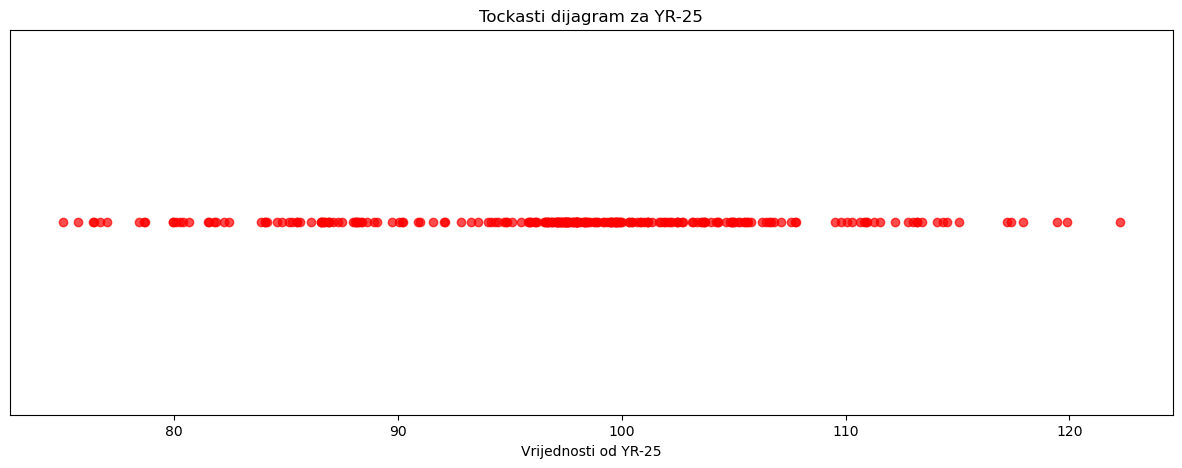

In [30]:
# BL YR-25

srednja_vrijednost_var1 = np.mean(df['YR-25']) # Aritmeticka sredina svih vrijednosti
st_devijacija_var1 = np.std(df['YR-25']) # Standardna devijacija
medijan_var1 = np.median(df['YR-25']) # Medijan
Q1_var1 = np.percentile(df['YR-25'], 25)  # Prvi kvartil; funkcija np.percentile() kao parametre prima objekt (prva vrijednost) 
# i broj izmedju 1 i 100 ukljucivo (druga vrijednost) koji kaze koji percentil niza gledamo. 25/100 = 1/4 pa gledamo 1. kvartil
Q3_var1 = np.percentile(df['YR-25'], 75)  # Treći kvartil 
#Ispis opcionalan
print(f"""'YR-25':
- Srednja vrijednost: {srednja_vrijednost_var1:.2f}  
- Standardna devijacija: {st_devijacija_var1:.2f}
- Medijan (Q2): {medijan_var1:.2f}
- Prvi kvartil (Q1): {Q1_var1:.2f}
- Treći kvartil (Q3): {Q3_var1:.2f}""") 
# Ovakav nacin ispisa znaci da varijablu ispisujemo u obliku realnog broja (floata) zaokruzenog na 2 decimalna mjesta

# Alternativno se moglo dobiti ispis koji sadrzi iste podatke o 'YR-25' s df['YR-25'].describe()

# Tockasti dijagram za YR-25
plt.figure(figsize=(15,5)) # Postavljanje velicine grafa
plt.scatter(df["YR-25"], [1]*len(df["YR-25"]), color='red', alpha=0.7) 
# Crtanje grafa (prvi param. su vrijednosti za x os, drugi za y os, treci boja, zadnji prozirnost tocaka)

plt.xlabel("Vrijednosti od YR-25") # Oznake x osi
plt.title("Tockasti dijagram za YR-25") # Naziv grafa

plt.yticks([])  # Sakrijemo y os jer nije potrebna
plt.show() # Prikaz grafa

'YR-26':
- Srednja vrijednost: 87.46
- Standardna devijacija: 7.83
- Medijan (Q2): 88.70
- Prvi kvartil (Q1): 82.21
- Treći kvartil (Q3): 93.49


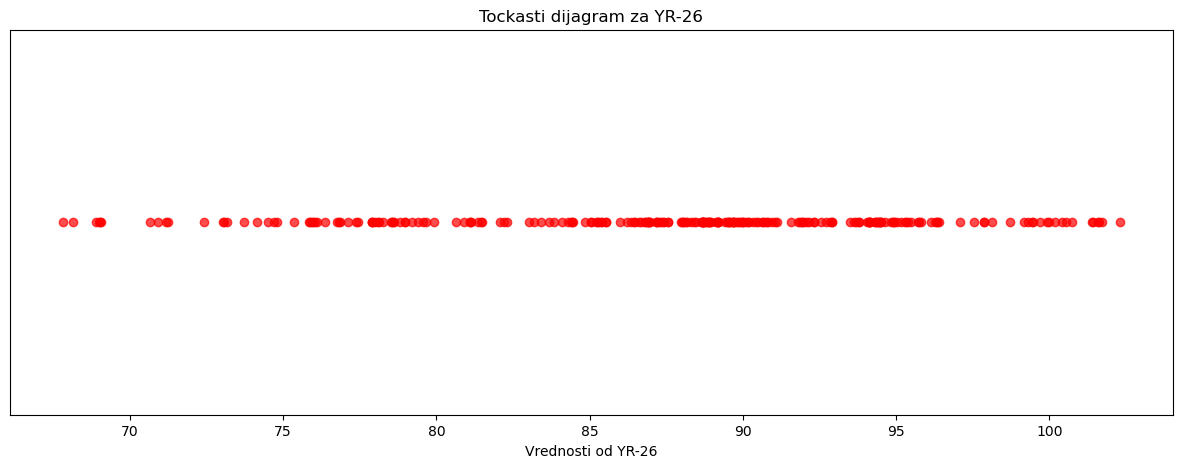

In [29]:
# BL YR-26

srednja_vrijednost_var2 = np.mean(df['YR-26'])
st_devijacija_var2 = np.std(df['YR-26'])
medijan_var2 = np.median(df['YR-26'])
Q1_var2 = np.percentile(df['YR-26'], 25)  # Prvi kvartil
Q3_var2 = np.percentile(df['YR-26'], 75)  # Treći kvartil 
#Ispis opcionalan
print(f"""'YR-26':
- Srednja vrijednost: {srednja_vrijednost_var1:.2f}
- Standardna devijacija: {st_devijacija_var1:.2f}
- Medijan (Q2): {medijan_var1:.2f}
- Prvi kvartil (Q1): {Q1_var1:.2f}
- Treći kvartil (Q3): {Q3_var1:.2f}""")

# Alternativno se moglo dobiti ispis koji sadrzi iste podatke o 'YR-26' s df['YR-26'].describe()

#Tockasti dijagram za YR-26
plt.figure(figsize=(15,5)) # Postavljanje velicine grafa
plt.scatter(df["YR-26"], [1]*len(df["YR-26"]), color='red', alpha=0.7) 
# Crtanje grafa (prvi param. su vrijednosti za x os, drugi za y os, treci boja, zadnji prozirnost tocaka)

plt.xlabel("Vrijednosti od YR-26") # Oznake x osi
plt.title("Tockasti dijagram za YR-26") # Naziv grafa

plt.yticks([])  # Sakrijemo y os jer nije potrebna
plt.show() # Prikaz grafa

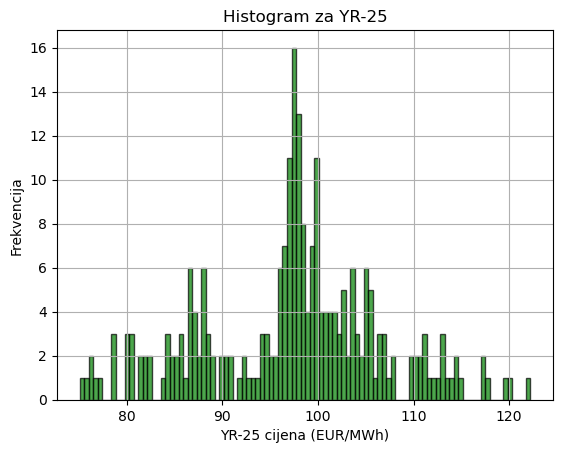

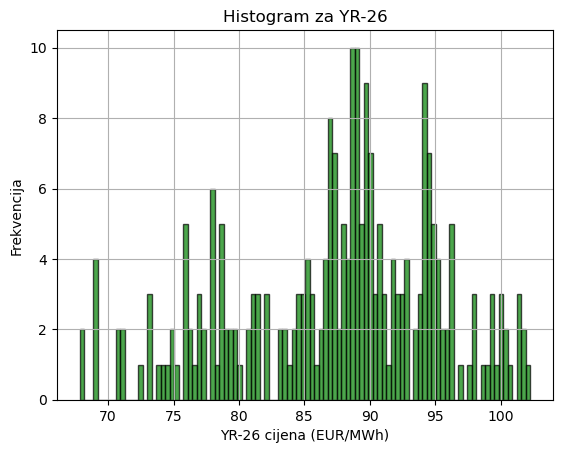

In [6]:
# Histogram za YR-25
df['YR-25'].hist(bins=100, color='green', edgecolor='black', alpha=0.7)
# prvi param. je broj "koseva" (ekvidistantni intervali u kojima se nalazi cijeli skup podataka), drugo boje ispune, 
# trece boja ruba (zbog boljeg kontrasta) i zadnje prozirnost)

plt.xlabel("YR-25 cijena (EUR/MWh)")
plt.ylabel("Frekvencija")
plt.title("Histogram za YR-25")
plt.show()

# Histogram za YR-26
df['YR-26'].hist(bins=100, color='green', edgecolor='black', alpha=0.7)

plt.xlabel("YR-26 cijena (EUR/MWh)")
plt.ylabel("Frekvencija")
plt.title("Histogram za YR-26")
plt.show()

# Testiranje jednakosti varijance i očekivanja

Provodimo test jednakosti varijance (F-test) odabranih statističkih varijabli.

Pretpostavka je da su njihove varijance jednake, tj. $H_0: \sigma_1^2 = \sigma_2^2$. U slučaju da se naša pretpostavka pokaže krivom, formiramo i kontrahipotezu, tj. $H_a: \sigma_1^2 \neq \sigma_2^2$.

Koristimo F-test koji se zasniva na činjenici da je $\sigma_1^2 / \sigma_2^2$ slučajna vrijednost Fisherove razdiobe s (245-1, 245-1) stupnjeva slobode (imamo 245 podataka). Potom, ako je izračunata vrijednost manja od $F_{0.05}(244, 244)$, hipoteza je dobra. Ukoliko p-vrijednost testa bude manja od 0.05 (nivo signifikantnosti), hipotezu ćemo odbaciti.

Napomena: nije najtočnije napisano $\sigma_1^2 / \sigma_2^2$ jer se ne radi o općoj standardnoj devijaciji već o onoj izračunatoj u naših 245 podataka. Pravilno bi bilo napisati $s_1^2 / s_2^2$.

In [4]:
from scipy import stats # u ovoj biblioteci se nalaze potrebni testovi

f_stat, f_p_val = stats.f_oneway(df["YR-25"], df["YR-26"]) 
# jednostavni ANOVA test za usopredjivanje srednjih vrijednosti između dviju skupina; YR-25 i YR-26
print(f'p-vrijednost = {f_p_val}, F-statistika = {f_stat}')

p-vrijednost = 8.053911190339911e-32, F-statistika = 159.40892271241583


Dobili smo negativan rezultat na F-testu (Mala p-vrijednost (znatno manja od 5% - nivoa značajnosti)) sto znači da nema dovoljno dokaza da se odbaci nulta hipoteza o jednakosti varijanci između grupa. Zato nema smisla provoditi test jednakosti očekivanja jer se već pretpostavlja da varijance između grupa nisu jednake.

Hipoteza bi se mogla parafrazirati na sljedeći način: $H_0:$ "Pretpostavljamo da je amplituda u skokovima cijena jednaka u oba skupa." 

Iz dobivenih podataka zaključujemo kako to nije tako. Također, vizualnom inspekcijom histograma lako se primjećuje da to nije slučaj (što predstavlja još jednu potvrdu ovog testa) (jedan je blize Poissonovoj distribuciji, dok je drugi blize uniformnoj).

Ovo se može objasniti time da su cijene za Y+1 u odnosu na Y+2 znatno volatilnije - jednostavno se više trguje njima i proizvod ima kraći rok trajanja na tržištu koje je samo po sebi podložno promjenama u kratkom roku.

# Varijanca i kovarijanca
Formula za kovarijancu: $\text{Cov}(X, Y) = \frac{\sum_{i=1}^{n} (X_i - \bar{X}) (Y_i - \bar{Y})}{n-1}$

Formula za koeficijent korelacije: $
r = \frac{\text{Cov}(X, Y)}{\sigma_X \cdot \sigma_Y}
$

In [23]:
# Pripadna kovarijanca i koeficiejent korelacije

kovarijanca_matr = np.cov(df["YR-25"], df["YR-26"])  # Matrica kovarijance- kvadratna matrica na cijoj su dijagonali 
# varijance stat. varijabli, a na ostalim pozicijma medusobne kovarijance
kovarijanca = kovarijanca_matr[0, 1]  # Vrijednost iz prvog reda(indeks 0) i drugog stupca (indeks 1) matrica kovarijance, tj.
#kovarijanca izmedu stat. varijabli "YR-25" i "YR-26" - ekstrakcija te vrijednosti

# Alternativno se moglo dobiti kovarijancu s kovarijanca = df["YR-25"].cov(df["YR-26"])

korelacija_matr = np.corrcoef(df["YR-25"], df["YR-26"])  # Korelacijska matrica- na mjestu (i,j) prikazuje korelacijski koeficijent 
# izmedu stat. varijabli Xi i Xj. Napomena: na dijagonali imamo vrijednosti 1 jer je svaki element ima koef. korelacije 1 sam sa 
# sobom, a matrica je simetricna jer vrijedi corrcoef(X, Y) = corrcoef(Y, X)
korelacija = korelacija_matr[0, 1]  # Imamo 2 varijable pa uzmemo vrijednost iz prvog reda(indeks 0) i drugog stupca (indeks 1) 
# matrica kovarijance, tj. kovarijanca izmedu stat. varijabli "YR-25" i "YR-26"

# Alternativno se moglo dobiti koeficijent korelacije s koef_korelacije = df["YR-25"].corr(df["YR-26"])

print(f"""Odnosi izmedu 'YR-25' i 'YR-26':
- Kovarijanca: {kovarijanca:.2f}
- Koeficijent korelacije: {korelacija:.3f}""")

Odnosi izmedu 'YR-25' i 'YR-26':
- Kovarijanca: 71.05
- Koeficijent korelacije: 0.967


# Zaključak na temelju dobivenih podataka

Prva faza analize podataka daje nam ideju o distribuciji cijena struje po proizvodima.

Tako za BL YR-25 imamo slučaj da je Settlement price 25% dana 2024. na koje je radila burza bilo manje ili jednako 90.99 EUR (prvi kvartil), a 25% više 102.70 EUR (treći kvartil). Također, pola dana je cijena bila viša od 97.96 EUR (medijan), dok je prosječna cijena bila ${\mu}$ = 97.32 EUR.

Nadalje, standardna devijacija od ${\sigma}$ = 9.35 nam daje ograde oko kojih možemo očekivati većinu podataka. Tako se 68% dana cijena nalazila u rasponu 97.32 $\pm {\sigma}$ EUR, 95% dana u rasponu 97.32 $\pm 2{\sigma}$ EUR, 99.7% dana u rasponu 97.32 $\pm 3{\sigma}$ EUR.

Za BL YR-26 imamo slučaj da je Settlement price 25% dana 2024. na koje je radila burza bilo manje ili jednako 82.21 EUR (prvi kvartil), a 25% više 93.49 EUR (treći kvartil). Također, pola dana je cijena bila viša od 88.70 EUR (medijan), dok je prosječna cijena bila ${\mu}$ = 87.46 EUR.

Nadalje, standardna devijacija od ${\sigma}$ = 7.83 nam daje ograde oko kojih možemo očekivati većinu podataka. Tako se 68% dana cijena nalazila u rasponu 87.46 $\pm {\sigma}$ EUR, 95% dana u rasponu 87.46 $\pm 2{\sigma}$ EUR, 99.7% dana u rasponu 87.46 $\pm 3{\sigma}$ EUR.

Gaussova krivulja u oba slučaja (histograma) blago je pomaknuta ulijevo, što možemo zaključiti iz činjenice da je medijan veći od srednje vrijednosti. Zbog ograničenog broja podataka teško je sa sigurnošću utvrditi da razdioba striktno slijedi Poissonovu distribuciju. Međutim, za proizvod YR-25 može se reći da pokazuje izraženije karakteristike Poissonove razdiobe, s manjim odstupanjima i manje izraženim dodatnim vrhovima. S druge strane, proizvod YR-26 pokazuje značajnije varijacije i nagle skokove u frekvencijama, zbog čega se čini kao kombinacija Poissonove i uniformne razdiobe. Na temelju dostupnih podataka teško je precizno definirati stvarnu distribuciju za ovaj proizvod. Odstupanja među krivuljama javljaju se zbog manje volatilnosti cijena proizvoda koji su više unaprijed (diskutirano ispod paragrafa Testiranje varijance i očekivanja).

Kovarijanca je 71.05, što je broj veći od nule i relativno velik u odnosu na ograde iz gornjeg dijela analize, pa to upućuje na linearnu povezanost dviju varijabli. Ipak, samu povezanost ipak djeluje lakše očitati iz koeficijenta korelacije.

Koeficijent korelacije od 0.967 ukazuje na snažnu povezanost između dviju varijabli (veći je od nule – kako jedna raste, tako i druga raste, skoro 1 – promjena vrijednosti po (mjerljivoj) jedinici jedne i druge varijable praktički identična). Napomenimo također da korelacija ne implicira uzročnost, stoga nije nužno točno da promjena u cijeni proizvoda BL YR-25 uzrokuje promjenu u cijeni proizvoda BL YR-26.

# Linearna regresija

Prvo smo napravili usporedbu cijena za proizvode YR-25 i YR-26 u odnosu na vrijeme te uočavamo pravilnosti u kretanju cijena izmedu ta dva proizvoda. Grafovi funkcija YR-25(t) i YR-26(t) prate trendove (oblik) u monotonostima jednoga i drugoga. Stoga, ima smisla napraviti regresiju između tih proizvoda. Najjednostavnija regresija je linearna, a u ovom slučaju ona čini dobar model.

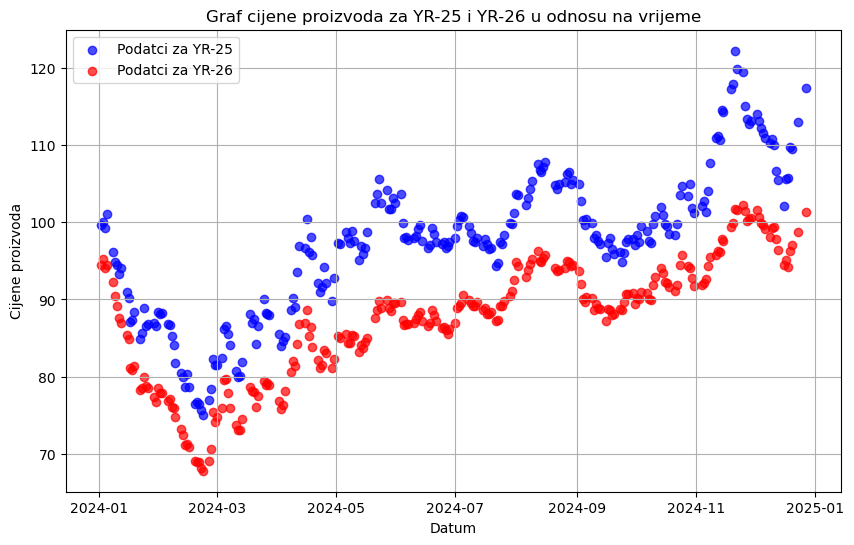

In [5]:
plt.figure(figsize=(10,6)) 
plt.scatter(df["Datum"], df["YR-25"],  color='blue', alpha=0.7, label="Podatci za YR-25")  # Crtanje grafa
plt.scatter(df["Datum"], df["YR-26"],  color='red', alpha=0.7, label="Podatci za YR-26")  # Crtanje grafa
plt.xlabel("Datum") # Oznake x osi
plt.ylabel("Cijene proizvoda") # Oznake y osi
plt.title("Graf cijene proizvoda za YR-25 i YR-26 u odnosu na vrijeme") # Naziv grafa
plt.legend() # Prikaz legende na grafu
plt.grid(True)  # Dodali smo mrezu radi bolje uocljivosti
plt.show() # Prikaz grafa

Sve diskutirano u gornjem dijelu pokazano je i na ovom točkastom grafu. "Linije se prate", osim u dijelovima u kojima tok grafa prve varijable naglo mijenja tok, tada razlika izmedju cijena za jednu i drugu godinu postaje očitija. 

Provedimo sada linearnu regresiju.

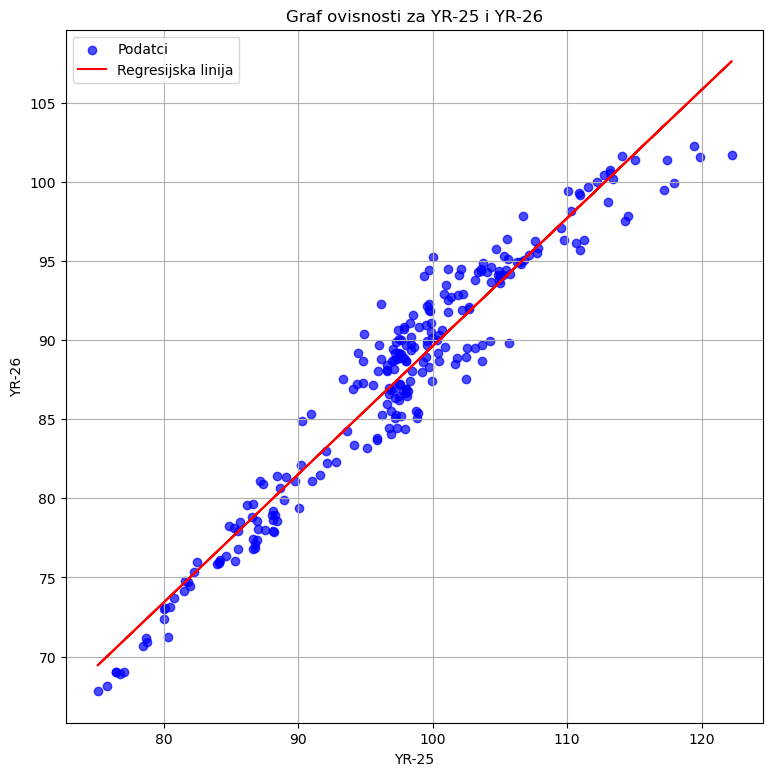

0.809268235466411


In [5]:
# Nezavisna varijabla biti ce YR-25, a zavisna YR-26

a, b = np.polyfit(df["YR-25"], df["YR-26"], 1)  
# Metoda najmanjih kvadrata za polinomijalnu regresiju; 1 (stupanj polinoma) označava linearnu regresiju- pravac (y = ax + b)

# Graf koji prikazuje odnos izmedu YR-25 i YR-26

plt.figure(figsize=(9,9))  # Velicina grafa
plt.scatter(df["YR-25"], df["YR-26"], color='blue', alpha=0.7, label="Podatci")  # Crtanje grafa
plt.plot(df["YR-25"], a*df["YR-25"] + b, color='red', label="Regresijska linija") # Crtanje pravca regresije

plt.xlabel("YR-25") # Oznake x osi
plt.ylabel("YR-26") # Oznake y osi
plt.title("Graf ovisnosti za YR-25 i YR-26") # Naziv grafa
plt.legend() # Prikaz legende na grafu
plt.grid(True)  # Dodali smo mrezu radi bolje uocljivosti
plt.show() # Prikaz grafa
print(a)

# Zaključak na temelju dobivenih podataka

Provođenjem linearne regresije, na način da fiksiramo **BL YR-25** kao nezavisnu varijablu i gledamo kako se mijenjaju vrijednosti od **BL YR-26** u odnosu na promjene nezavisne varijable, dobijemo pravac koji najbolje opisuje situaciju. Sada, možemo predvidjeti koja bi cijena bila za BL YR-26 za danu cijenu od BL YR-25.

Uocavamo kako je regresijska analiza bila od velike korisnosti jer je samo potvrdila nasa nagadanja o velikoj povezanosti statistickih varijabli. Sada, uocavamo kako je povezanost linearna.

Kako bismo bili skroz točni, trebali bismo prvo validirati model dobiven linearnom regresijom, no taj je dio u drugoj zadaći. Za sada, uviđamo iz grafičkog prikaza kako je model zasnovan na linearnoj regresiji korektan i dobro opisuje ove podatke.